In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [2]:
from tqdm import tqdm

In [3]:
_file = "../../data/tng100_trees.npz"
with open(_file, 'rb') as fp:
    trees_data = np.load(fp)
    matches = trees_data['matches']
    bdmo = trees_data['bdmo']
    tdmo = trees_data['tdmo']
    bbar = trees_data['bbar']
    tbar = trees_data['tbar']
    


In [4]:
matches.shape, bdmo.shape, bbar.shape, tdmo.shape, tbar.shape

((153348,), (869229,), (153348,), (869229, 100), (153348, 100))

In [5]:
bbar.dtype, bdmo.dtype, tbar.dtype, tdmo.dtype

(dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8'), ('stellar_mass', '<f4')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8')]))

In [9]:
def _get_mah_interpolated(mvir):
    assert mvir.shape[1] == 100
    n_snaps = 100
    n_haloes = mvir.shape[0]
    mah = np.zeros((n_haloes, n_snaps)) * np.nan

    for ii in tqdm(range(n_haloes)):

        mdm = mvir[ii, :]
        _mask = mdm == 0.0
        mdm[_mask] = np.nan

        # linearly interpolate nan values
        mdm = pd.Series(mdm)
        mdm = mdm.interpolate(method="linear", limit_direction="both", axis=0)
        mah[ii] = mdm.values
    
    return mah


def _get_a12_from_mpeak_mah(mpeak_mah, scales):
    # get a_{1/2} (correctly with interpolation)
    assert scales.shape[0] == mpeak_mah.shape[1]
    n_haloes = mpeak_mah.shape[0]
    a12 = np.zeros(n_haloes)
    for ii in range(n_haloes):
        mah_ii = mpeak_mah[ii]
        a12[ii] = np.interp(0.5, mah_ii, scales)
    return a12

In [125]:
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
redshift_snaps = metadata['Redshift'].values
scales = 1 / (1 + redshift_snaps)
scales

array([0.04750594, 0.06253909, 0.0770416 , 0.08347245, 0.09090909,
       0.09624639, 0.1       , 0.10582011, 0.11098779, 0.11627907,
       0.12135922, 0.12484395, 0.13351135, 0.14265335, 0.1459854 ,
       0.15313936, 0.16051364, 0.16666667, 0.17667845, 0.18416206,
       0.19305019, 0.1996008 , 0.21231423, 0.22271715, 0.23364486,
       0.24937656, 0.25641026, 0.26809651, 0.27932961, 0.29069767,
       0.30120482, 0.31152648, 0.32258065, 0.33333333, 0.34482759,
       0.35460993, 0.3649635 , 0.37453184, 0.38461538, 0.39525692,
       0.4       , 0.41493776, 0.42372881, 0.43478261, 0.44444444,
       0.45248869, 0.46511628, 0.47393365, 0.48309179, 0.49019608,
       0.5       , 0.51282051, 0.52083333, 0.52910053, 0.54054054,
       0.54945055, 0.55865922, 0.56818182, 0.57803468, 0.58823529,
       0.5952381 , 0.6097561 , 0.61728395, 0.625     , 0.63291139,
       0.64516129, 0.65789474, 0.66666667, 0.67567568, 0.68493151,
       0.69444444, 0.70422535, 0.71428571, 0.72463768, 0.73529

# DMO

In [10]:
mask = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])
sum(mask) / len(mask), len(mask)

(np.float64(0.6139624885962157), 869229)

In [11]:
# percentage of bad trees that are not "OK"
# this flag captures all cases we care about
sum(mask), sum(tdmo['ok'][:, -1])

(np.int64(533674), np.int64(533674))

In [12]:
mah = _get_mah_interpolated(tdmo['mdm'][mask])

100%|██████████| 533674/533674 [00:31<00:00, 16715.93it/s]


In [13]:
# get mpeak
from multicam_tng.utils import get_mpeak_from_mah
mpeak_mah = get_mpeak_from_mah(np.log10(mah))
mpeak_mah.shape

(533674, 100)

In [15]:
a12 = _get_a12_from_mpeak_mah(mpeak_mah, scales)

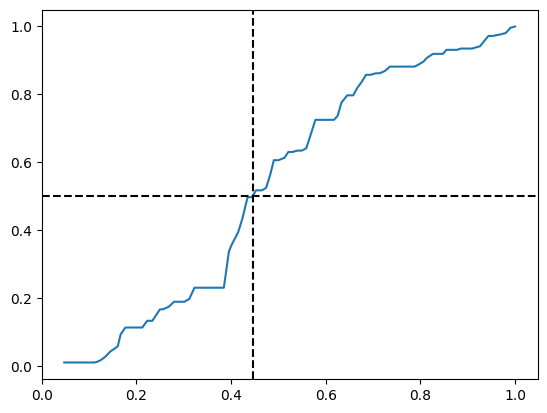

In [189]:
# example to sanity check
idx = np.random.randint(mpeak_mah.shape[0])
mah_ex = mpeak_mah[idx]

plt.plot(scales, mah_ex)
plt.axvline(a12[idx], ls='--', c='k')
plt.axhline(0.5, ls='--', c='k')

In [117]:
np.unique(a12).shape[0], len(a12)  # a lot more unique values

(514739, 533674)

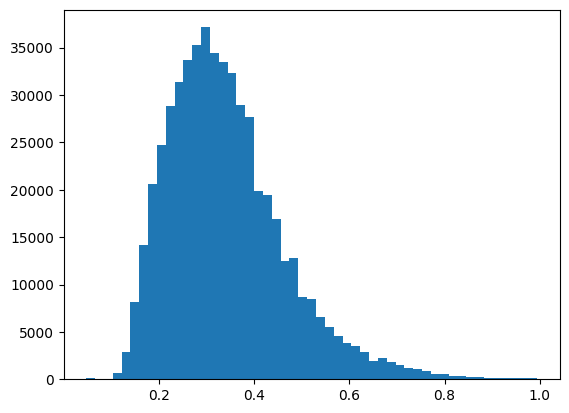

In [118]:
plt.hist(a12, bins=51);

In [119]:
# apply mkas universally
subfind_id = tdmo['subfind_id'][:, -1][mask]
vpeak_pre = bdmo['vpeak_pre'][mask]
vpeak = bdmo['vpeak'][mask]
mpeak_pre = bdmo['mpeak_pre'][mask]
mpeak = bdmo['mpeak'][mask]
is_sub = tdmo['is_sub'][:, -1][mask]
subfind_id.shape, vpeak_pre.shape, is_sub.shape, mpeak_mah.shape, a12.shape

((533674,), (533674,), (533674,), (533674, 100), (533674,))

In [120]:
out = {
    'subfind_id': subfind_id, 
    'vpeak_pre': vpeak_pre,
    'vpeak': vpeak,
    'mpeak_pre': mpeak_pre,
    'mpeak': mpeak,
    'mah': mah,
    'is_sub': is_sub,
    'mpeak_mah': mpeak_mah,
    'a12': a12,
}

with open("../../data/out-trees-tng100-dmo.npz", 'wb') as fp:
    np.savez(fp, **out)

# Baryons

In [126]:
mask = (tbar['ok'][:, -1]) & (tbar['mdm'][:, -1] > 0) & (~bbar['is_err'])
sum(mask) / len(mask), len(mask)

(np.float64(0.6614432532540365), 153348)

In [127]:
mah = _get_mah_interpolated(tbar['mdm'][mask])

100%|██████████| 101431/101431 [00:06<00:00, 16637.59it/s]


In [128]:
# get mpeak
from multicam_tng.utils import get_mpeak_from_mah
mpeak_mah = get_mpeak_from_mah(np.log10(mah))
mpeak_mah.shape

(101431, 100)

In [129]:
a12 = _get_a12_from_mpeak_mah(mpeak_mah, scales)

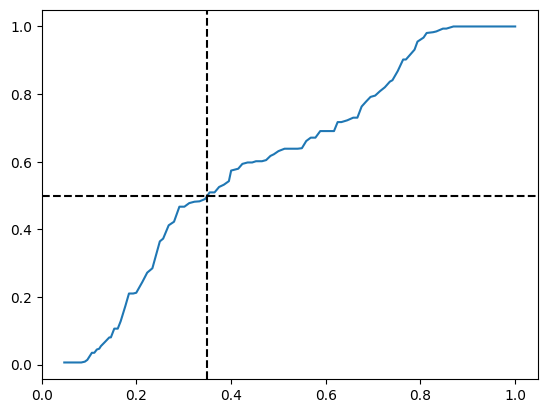

In [190]:
# example to sanity check
idx = np.random.randint(mpeak_mah.shape[0])
mah_ex = mpeak_mah[idx]

plt.plot(scales, mah_ex)
plt.axvline(a12[idx], ls='--', c='k')
plt.axhline(0.5, ls='--', c='k')

In [191]:
# apply mkas universally
subfind_id = tbar['subfind_id'][:, -1][mask]
vpeak_pre = bbar['vpeak_pre'][mask]
vpeak = bbar['vpeak'][mask]
mpeak_pre = bbar['mpeak_pre'][mask]
mpeak = bbar['mpeak'][mask]
is_sub = tbar['is_sub'][:, -1][mask]
stellar_mass = tbar['stellar_mass'][:, -1][mask]
subfind_id.shape, vpeak_pre.shape, is_sub.shape, mpeak_mah.shape, a12.shape, stellar_mass.shape

((101431,), (101431,), (101431,), (101431, 100), (101431,), (101431,))

In [192]:
out = {
    'subfind_id': subfind_id, 
    'vpeak': vpeak,
    'mpeak_mah': mpeak_mah,
    'is_sub': is_sub,
    'a12': a12,
    'mpeak_pre': mpeak_pre,
    'mpeak': mpeak,
    'stellar_mass': stellar_mass,
}

with open("../../data/out-trees-tng100-bar.npz", 'wb') as fp:
    np.savez(fp, **out)

# Matches

In [193]:
mask_bar = mask = (tbar['ok'][:, -1]) & (tbar['mdm'][:, -1] > 0) & (~bbar['is_err'])
mask_dmo = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])


In [194]:
# repetitions
print(len(set([m.item() for m in matches])), len(matches))

#repetitions all come from "-1" placeholder element
print(sum(matches == -1) + len(set([m.item() for m in matches])) - 1) 

# indices range
matches.max(), bdmo.shape

143016 153348
153348


(np.int64(869228), (869229,))

In [195]:
# get inverse 
mask = matches != -1
index_bar = np.arange(len(bbar))
matches_dmo  = np.full(len(bdmo), fill_value=-1)
matches_dmo[matches[mask]] = index_bar[mask]
# mask2 = np.isin(np.arange(len(bdmo)), matches[mask1])
# assert sum(mask1) == sum(mask2)
# index_bar2 = index_bar[mask1]
# sort_mask = np.argsort(matches[mask1])


In [196]:
# sanity check
for ii, x in enumerate(matches):
    if x != -1:
        assert ii == matches_dmo[x]


In [197]:

out = {
    'matches_bar': matches[mask_bar],
    'matches_dmo': matches_dmo[mask_dmo],
}

with open("../../data/matches-trees-tng100.npz", 'wb') as fp:
    np.savez(fp, **out)

In [198]:
matches_dmo[mask_dmo].shape, matches[mask_bar].shape

((533674,), (101431,))

## How to get matched in order quantities


In [ ]:
with open("../../data/matches-trees-tng100.npz", 'rb') as fp:
    matches = np.load(fp)['matches_bar']

matches.shape

(101431,)

In [ ]:
# how to match baryons to dmo and get correct order.
mask = matches != -1
sort_mask = np.argsort(matches[mask]) # order corresponds to order in dmo table
x = bbar['vpeak'][mask][sort_mask]

In [ ]:
mask = matches_dmo != -1
y = bdmo['vpeak'][mask] # already ordered
y.shape

(143015,)

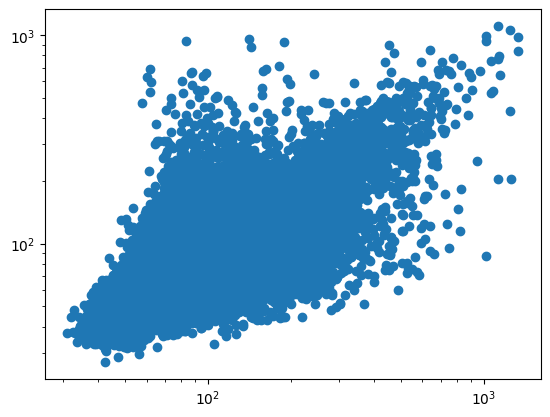

In [ ]:
plt.loglog(x, y, 'o')